In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.api import OLS, add_constant
from statsmodels.tsa.arima.api import ARIMA
from scipy.stats import skew, kurtosis

### 1

$ r_{t}=\mu +\sigma \varepsilon _{t}+J_{t}\ and \ J_{t}=B_{t}\times \left( \mu _{j}+\sigma _{j}\delta _{t}\right) $$

The expectation is as follows:
$$ E\left[ r_{f}\right] =\mu +p\mu _{j}  $$

The variance is as follows:
$$ Var\left[ r_{t}\right] =p\mu _{j}^{2}\left( 1-p\right) +p^{2}\sigma _{j}^{2}+\sigma ^{2} $$

The skew is derived as follows:
Skew = $$ \dfrac{E\left[ \left( r_{t}-E\left[ r_{t}\right] \right) ^{3}\right] }{\ {var}\left( r_{t}\right) ^{3/2}} $$
$$ r_{t}-E\left[ r_{t}\right]  = \mu +\sigma \varepsilon _{{t}}+J_{t} -\mu -p\mu _{j}= \sigma \varepsilon _{t} + J_{t}-p\mu _{j} $$
$$ \mathbb{E}\!\left[\left(\sigma \varepsilon_t + (J_t - p\mu_j)\right)^3\right] $$

$$ \mathbb{E}\!\left[(\sigma\varepsilon_t + (J_t-p\mu_j))^3\right]
= \mathbb{E}\!\left[(\sigma\varepsilon_t)^3\right] + \mathbb{E}\!\left[(J_t-p\mu_j)^3\right] + 3\,\mathbb{E}\!\left[(\sigma\varepsilon_t)^2\right]\mathbb{E}\!\left[J_t-p\mu_j\right] + 3\,\mathbb{E}\!\left[\sigma\varepsilon_t\right]\mathbb{E}\!\left[(J_t-p\mu_j)^2\right]. $$


 Given that: $$ E\left[ \left( \sigma \varepsilon _{t}\right) \right] =\sigma E\left[ \varepsilon _{t}\right] =\sigma0 $$ and also $$E\left[ J_t\right] =p\mu _{i} E[ J_t\ -p\mu _{j}] =0 $$

$$\mathbb{E}\!\left[(J_t-p\mu_j)^3\right] = \mathbb{E}[J_t^3] -3p\mu_j\,\mathbb{E}[J_t^2] +3(p\mu_j)^2\,\mathbb{E}[J_t] -E[(p\mu_j)^3] $$

$$ = p\left( \mu ^{3}+3\mu _{j}\sigma _{j}^{2}\right) -3p\mu _{j}p\left( \mu _{j}^{2}+\sigma _{j}^{2}\right) +3\left( p\mu _{j}\right) ^{3}-\left( p\mu _{j}\right) ^{3} =
3p\mu _{j}\sigma _{j}^{2}\left( 1-p\right) +p\mu _{j}^{3}\left( 1-3p+2p^{2}\right) $$

So skew is equal to:

 $$=\dfrac{3p\mu _{j}\sigma _{j}^{2}\left( 1-p\right) +p\mu _{j}^{3}\left( 1-3p+2p^{2}\right) } {\left( p\mu _{j}^{2}\left(1-p\right) +p\sigma _{j}^{2}+\sigma ^{2}\right) ^{3/2}} $$

Lastly the Kurtosis is derived as follows:
$$ K\left( r_{t}\right) =E\left[ \dfrac{\left( r_{t}-E\left[ r_{t}\right] \right) ^{4}}{var\left( r_{t}\right) ^{2}}\right] $$

using $$ r_{t}-E\left[ r_{t}\right] = \sigma \varepsilon _{t}+J _{t}-p\mu _{j} $$

$$ E\left[ \left( \sigma \varepsilon _{t}+J_{t}-p\mu _{j}\right) ^{4}\right] = E\left[ \left( \sigma \varepsilon _{t}\right) ^{4}\right] +4E\left[ \left( \sigma {\varepsilon_t}\right) ^{3}\left( J_{t}-p\mu _{t}\right) \right] + 6\,\mathbb{E}\!\left[\left(\sigma\varepsilon_t\right)^2\left(J_t-p\mu_j\right)^2\right] +4\,\mathbb{E}\!\left[\left(\sigma\varepsilon_t\right)\left(J_t-p\mu_j\right)^3\right] +\mathbb{E}\!\left[\left(J_t-p\mu_j\right)^4\right]$$

But we have
1) $$E\left[ \left( \sigma \varepsilon _{t}\right) ^{4}\right]  $$ leads to $$ 3\sigma ^{4}$$ from normal distribution having kurtosis 3.
2) $$ 4E\left[ \left( \sigma {\varepsilon_t}\right) ^{3}\left( J_{t}-p\mu _{t}\right) \right] $$ and $$4E\left[ (\sigma \varepsilon _{t})\left( J_{t}-p\mu _{j}\right) ^{3}\right] \ =0 $$

Thus we get: $$3\sigma ^{4}+6\sigma ^{2}\left[ p\left( \mu _{j}^{2}+\sigma _{j}^{2}\right) -\left( p\mu _{j}\right) ^{2}\right] +p\left( \mu _{j}^{4}+6\mu _{j}^{2}\sigma _{j}^{2}+3\sigma _{j}^{4}\right) -4p^2{\mu_j}\left( \mu ^{3}+3\mu _{j}\sigma _{j}^{2}\right)
 +6p^{3}\mu _{j}^{2}\left( \mu _{j}^{2}+\sigma _{j}^{2}\right) -3\left( p\mu _{j}\right) ^{4}$$

Which simplifies to:
$$ E\left[ \left( r_{t}-E\left[ r_{t}\right] \right) ^{4}\right] =3\sigma ^{4}+6\sigma ^{2}\left[ p\mu _{j}^{2}\left( 1-p\right) +p\sigma _{j}^{2}\right] +
p\left( \mu _{j}^{4}+6\mu_j^{2}\sigma _{j}^{2}+3\sigma _{j}^{4}\right) -4p^{2}\mu _{j}\left( \mu _{j}^{3}+3\mu _{j}\sigma _{j}^{2}\right) +6p^{3}\mu _{j}^{2}\left( \mu _{j}^{2}+\sigma _{j}^{2}\right) -3\left( p\mu _{j }\right) ^{4} $$

So:
$$ \begin{aligned} K(r_t) &= \frac{\mathbb{E}\!\left[\left(r_t-\mathbb{E}[r_t]\right)^4\right]} {\left(p(1-p)\mu_j^2 + p\sigma_j^2 + \sigma^2\right)^2}. \end{aligned} $$

Meaning thus excess kurtosis is:  $$ K\left( r_{t}\right) -3$$


### 2

In the log normal returns model we have:
$$r_t = \mu + \sigma \epsilon_t$$
where $r_t$ are the log returns, and $r_t \sim \mathcal{N}(\mu, \sigma^2)$.

In this case, the skewness of the model is:
$$\frac{E[(r_t-E[r_t])^3]}{\sigma^3} = 0$$

And the kurtosis:
$$\frac{E[(r_t-E[r_t])^4]}{\sigma^4} = 3$$

This means that under the log normal returns model we are expecting normal returns, that is symmetric, and no fat tails to it.

In contrast, when modelling returns we expect a left tail that is more pronounced than the right tail (negative skewness). That is because, many investments with high Sharpe ratios have strongly negatively skewed returns. In addition, returns generally show fat tails, so the kurtosis should be greater than 3. This is because when talking about returns, it is more likely to have an extreme scenario (eg. crashes) than it would be predicted by normal distributions.

Finally, the Bernoulli-normal mixture introduces jumps to the model. This jump means that shocks come periodically, without assuming a continuous and smooth release of information.

For these reasons, the Bernoulli-normal mixture is potentially a better model of returns

In [2]:
def normal_log_returns(T):
    return np.random.normal(loc=0.0004, scale=0.1**2, size=T)


def jump_log_returns(mu, sigma, p, mu_j, sigma_j, T):
    bt = np.random.binomial(n=1, p=p, size=T)
    jt = bt * (mu_j + sigma_j * np.random.normal(loc=0, scale=1, size=T))
    rt = mu + sigma * np.random.normal(loc=0, scale=1, size=T) + jt
    return rt

In [61]:
jump_sim = jump_log_returns(0.0004, 0.01, 0.01, -0.03, 0.04, 2500)
log_ret = normal_log_returns(12_500)
t = np.linspace(1, 12_500/250, num=len(log_ret))
t2 = np.linspace(1, 2500/250, num=len(jump_sim))
real_returns = pd.read_csv('homework3data.csv')
real_returns['year'] = real_returns['year'].astype(str)
real_returns['month'] = real_returns['month'].astype(str)
real_returns['date'] = real_returns['year'] + '-' + real_returns['month']
real_returns['date'] = pd.to_datetime(real_returns['date'], format='%Y-%m')

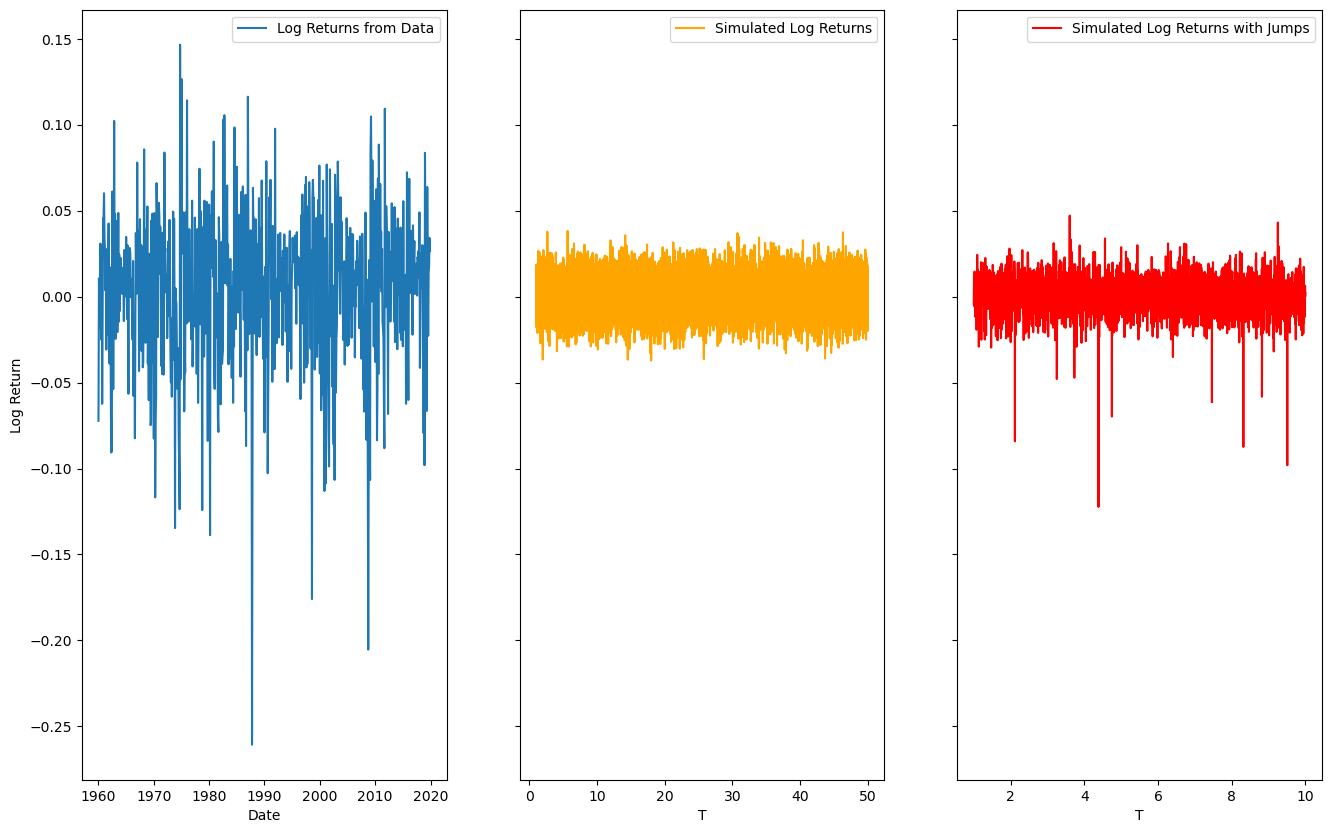

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 10), sharey=True)
sns.lineplot(data=real_returns, x='date', y='log_excess_ret', ax=axes[0], label='Log Returns from Data')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Log Return')
sns.lineplot(x=t, y=log_ret, label='Simulated Log Returns', ax=axes[1], color='orange')
axes[1].set_xlabel('T')
sns.lineplot(x=t2, y=jump_sim, label='Simulated Log Returns with Jumps', ax=axes[2], color='red')
axes[2].set_xlabel('T')
plt.show()

The basic log return model doesn't capture the full dynamics of the real world data. The real world data is much more volatile with periods of extreme volatility and plenty of outlier returns. The basic log return model is missing a jump component to model the crashes seen in the data.
Once we add in the jumps the model looks more like the data but still is not quite the same. We are missing a stochastic volatility component. The real world data exhibits volatility clustering that is not being captured by our Bernoulli-normal mixture model. In order to correct for this, we need our $\sigma$ component to vary through time. With properly estimated parameters, this would allow for the volatility clustering to be captured by our model. Furthermore, we can add in different kinds of jumps. There are some jumps that happen at known times, such as earnings releases, but there are also random jumps. By adding in two different jump components we could more accurately capture the timing of the jumps themselves. With stochastic volatility, pre-determined jumps, and random jumps we would have a much better model of returns.

In [5]:
log_mean = np.mean(log_ret)
log_std = np.std(log_ret)
log_skew = skew(log_ret)
log_kurtosis = kurtosis(log_ret, fisher=False)

jump_mean = np.mean(jump_sim)
jump_std = np.var(jump_sim)
jump_skew = skew(jump_sim)
jump_kurtosis = kurtosis(jump_sim, fisher=False)

pd.DataFrame({'Log Normal': [log_mean, log_std, log_skew, log_kurtosis],
              'Bernoulli': [jump_mean, jump_std, jump_skew, jump_kurtosis]},
             index=['Mean', 'SD', 'Skewness', 'Kurtosis'])

,Log Normal,Bernoulli
Mean,0.000469,0.000191
SD,0.010114,0.000129
Skewness,0.018199,-1.302249
Kurtosis,3.009031,13.925292


In [9]:
mu = 0.0004
sigma = 0.01
p = 0.01
mu_j = -0.03
sigma_j = 0.04

unconditional_mu = mu + p * mu_j
unconditional_variance = p * mu_j**2 * (1 - p) + p * sigma_j**2 + sigma**2
unconditional_skew = (3 * p * mu_j * sigma_j ** 2 * (1 - p) + p * mu_j**3 * (1- 3*p + 2 * p**2)) / ((p * mu_j**2 * (1-p) + p * sigma_j**2 + sigma**2) ** (3/2))
unconditional_kurtosis = (3 * (sigma ** 4) + 6 * (sigma ** 2) * (p * (mu_j ** 2) * (1 - p) + p * (sigma_j ** 2)) + p * (mu_j ** 4 + 6 * (mu_j ** 2) * (sigma_j ** 2) + 3 * (sigma_j ** 4)) - 4 * (p ** 2) * mu_j * (mu_j ** 3 + 3 * mu_j * sigma_j ** 2) + 6 * (p ** 3) * (mu_j ** 2) * ((mu_j ** 2) + (sigma_j ** 2)) - 3 * (p * mu_j) ** 4) / (unconditional_variance ** 2)
print(f'Unconditional Mean: {unconditional_mu}')
print(f'Unconditional SD: {np.sqrt(unconditional_variance)}')
print(f'Unconditional Skew: {unconditional_skew}')
print(f'Unconditional Kurtosis: {unconditional_kurtosis}')

Unconditional Mean: 0.00010000000000000005
Unconditional SD: 0.011176314240392492
Unconditional Skew: -1.2088206383710394
Unconditional Kurtosis: 13.729041146916632


# 4
Here we want to find the t-stat of the sample mean. In this case, the t-stat is given by:
$$t = \frac{\bar{r}-E[r_t]}{\sqrt{Var(\bar{r})}}$$

where:
$$\bar{r} = \frac{1}{T}\sum_{t=1}^Tr_t = \frac{1}{T}\sum_{t=1}^T(\mu + \sigma \epsilon_t + B_t(\mu_J + \sigma_J \delta_t)) = \mu + \frac{1}{T}\sigma \sum_{t=1}^T\epsilon_t + \frac{1}{T}\sum_{t=1}^T B_t(\mu_J + \sigma_J \delta_t)$$

From Question 1:
$$E[r_t] = \mu + p\mu_J$$

and the variance is given by:

$$Var(\bar{r}) = Var(\frac{1}{T}\sum_{t=1}^Tr_t)= \frac{1}{T^2}Var(\sum_{t=1}^Tr_t)$$
since we are assuming no autocorrelation we get:
$$\frac{1}{T^2}Var(\sum_{t=1}^Tr_t) = \frac{1}{T^2}\sum_{t=1}^TVar(r_t) = \frac{1}{T}Var(r_t)$$

operate under the null hypothesis that the population mean is zero:
$$H_0: E[r_t] = 0$$
This means that:
$$E[r_t] = \mu + p\mu_J = 0 \Rightarrow \mu = -p\mu_J $$

In [10]:
def samples_bernoulli(T):
    rt = jump_log_returns(mu, sigma, p, mu_j, sigma_j, T)
    return rt

def t_statistic(rt):
    T = len(rt)
    mean = np.mean(rt)
    var_mean = np.var(rt)
    std_mean = np.sqrt(var_mean / T)

    return mean / std_mean, mean

def monte_carlo(N, T):
    t_stats = np.zeros(N)
    sample_means = np.zeros(N)

    for nn in range(N):
        rt = samples_bernoulli(T)
        t_stats[nn] = t_statistic(rt)[0]
        sample_means[nn] = t_statistic(rt)[1]

    return t_stats, sample_means


def distribution_plots(year, t_stats, sample_means):

    print(f'Distribution plots for {year/250} years.')

    stand_norm = np.random.normal(0, 1, N)
    sns.histplot(x=t_stats[year], color='blue', label='t-stat')
    sns.histplot(x=stand_norm, color='red', alpha=0.3, label='Standard Normal')
    plt.title('Distribution of t-stat under $H_0$ vs. Standard Normal')
    plt.legend()
    plt.show()

    sns.histplot(x=sample_means[year], color='blue', label='Sample mean')
    plt.title('Distribution of sample means')
    plt.show()

Distribution plots for 0.1 years.


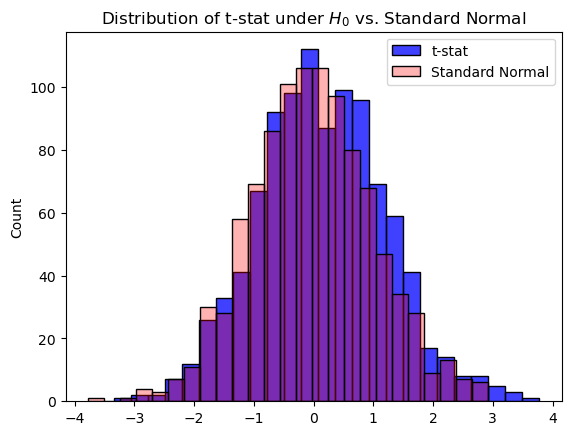

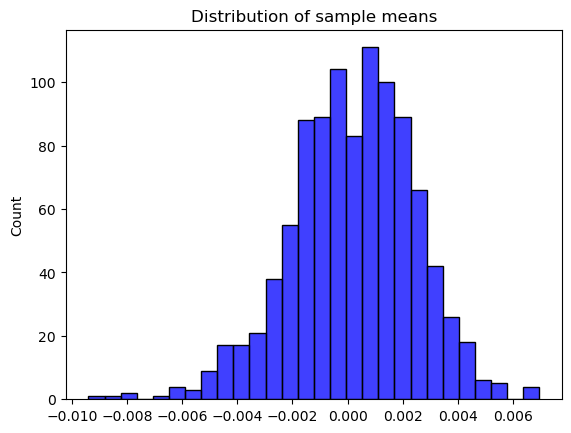

Distribution plots for 0.5 years.


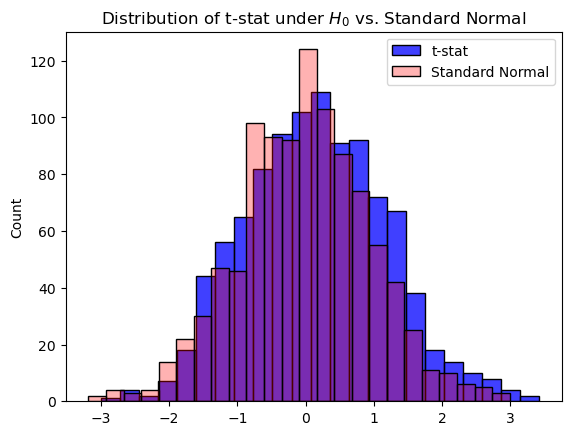

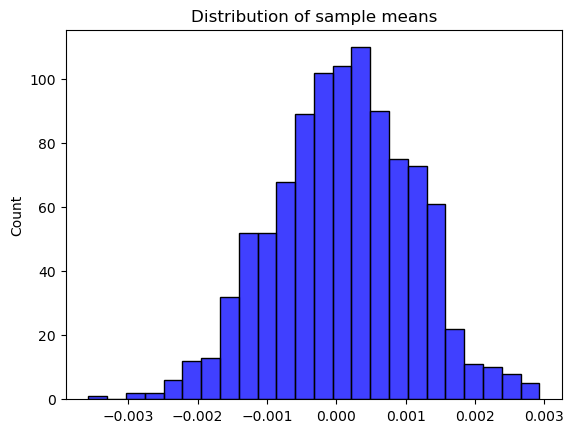

Distribution plots for 2.0 years.


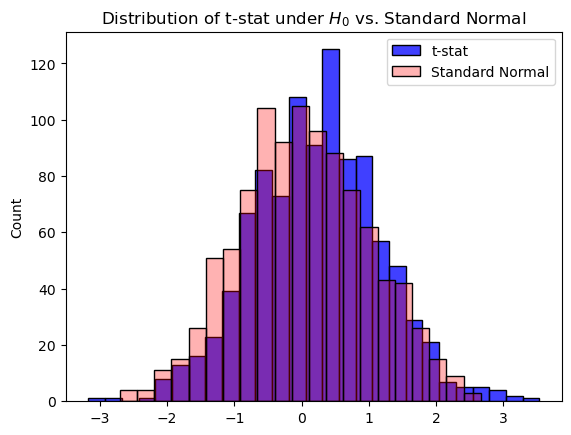

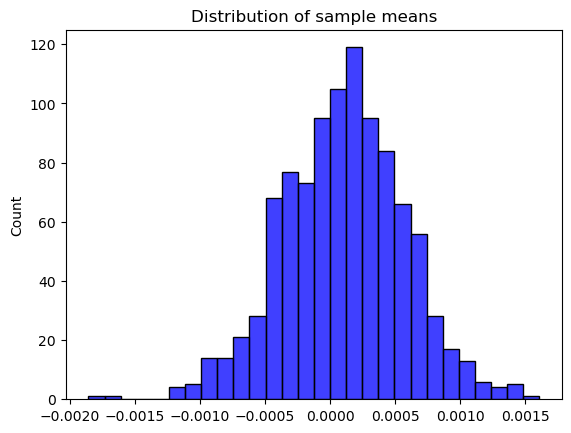

Distribution plots for 4.0 years.


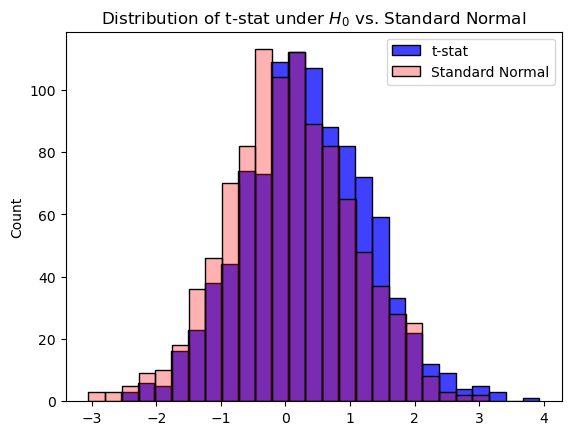

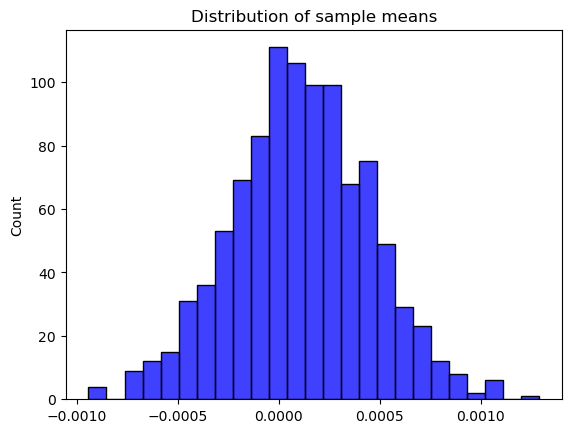

In [11]:
N = 1000
T = [25, 125, 500, 1000]
t_stats_dict = dict()
sample_mean_dict = dict()

for year in T:
    t_stats, sample_mean = monte_carlo(N, year)
    t_stats_dict[year] = t_stats
    sample_mean_dict[year] = sample_mean
    distribution_plots(year, t_stats_dict, sample_mean_dict)

In [14]:
for year in T:
    print(f'The t-stat and sample mean moments for {year} years:')
    df = pd.DataFrame({'t-stat': [np.mean(t_stats_dict[year]), np.std(t_stats_dict[year]), skew(t_stats_dict[year]), kurtosis(t_stats_dict[year])],
                        'Sample Mean': [np.mean(sample_mean_dict[year]), np.std(sample_mean_dict[year]), skew(sample_mean_dict[year]), kurtosis(sample_mean_dict[year])]},
                        index = ['Mean', 'STD','Skewness', 'Kurtosis'])
    print(df)

The t-stat and sample mean moments for 25 years:
            t-stat  Sample Mean
Mean      0.139976     0.000171
STD       1.073666     0.002245
Skewness  0.097050    -0.333958
Kurtosis  0.079074     0.607177
The t-stat and sample mean moments for 125 years:
            t-stat  Sample Mean
Mean      0.155544     0.000106
STD       1.026860     0.001005
Skewness  0.149194    -0.091499
Kurtosis -0.118643    -0.046503
The t-stat and sample mean moments for 500 years:
            t-stat  Sample Mean
Mean      0.220406     0.000100
STD       0.941541     0.000469
Skewness  0.047552    -0.109412
Kurtosis  0.214887     0.378880
The t-stat and sample mean moments for 1000 years:
            t-stat  Sample Mean
Mean      0.321807     0.000108
STD       0.975003     0.000342
Skewness  0.102763     0.005475
Kurtosis  0.138630     0.104937


# Question 2
### 1

In [62]:
real_returns['rt+1'] = real_returns['log_excess_ret'].shift(-1) * 12
real_returns.dropna(inplace=True)
X = real_returns['div_yld']
X = add_constant(X)
X.columns = ['alpha', 'dividend_yield']
y = real_returns['rt+1']

In [63]:
reg = OLS(y, X).fit(cov_type='HC3')
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   rt+1   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.243
Date:                Tue, 17 Feb 2026   Prob (F-statistic):              0.265
Time:                        23:01:39   Log-Likelihood:                -558.74
No. Observations:                 719   AIC:                             1121.
Df Residuals:                     717   BIC:                             1131.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
alpha             -0.0211      0.065     -0.323      0.747      -0.149       0.107
dividend_yield     2.5456      2.283      1.115      0.265      -1.929       7.020
==============================================================================
Omnibus:                      119.913   Durbin-Watson:                   1.830
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              323.841
Skew:                          -0.845   Prob(JB):                     4.77e-71
Kurtosis:                       5.820   Cond. No.                         101.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [64]:
print(reg.t_test('dividend_yield = 0'))

                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             2.5456      2.283      1.115      0.265      -1.929       7.020


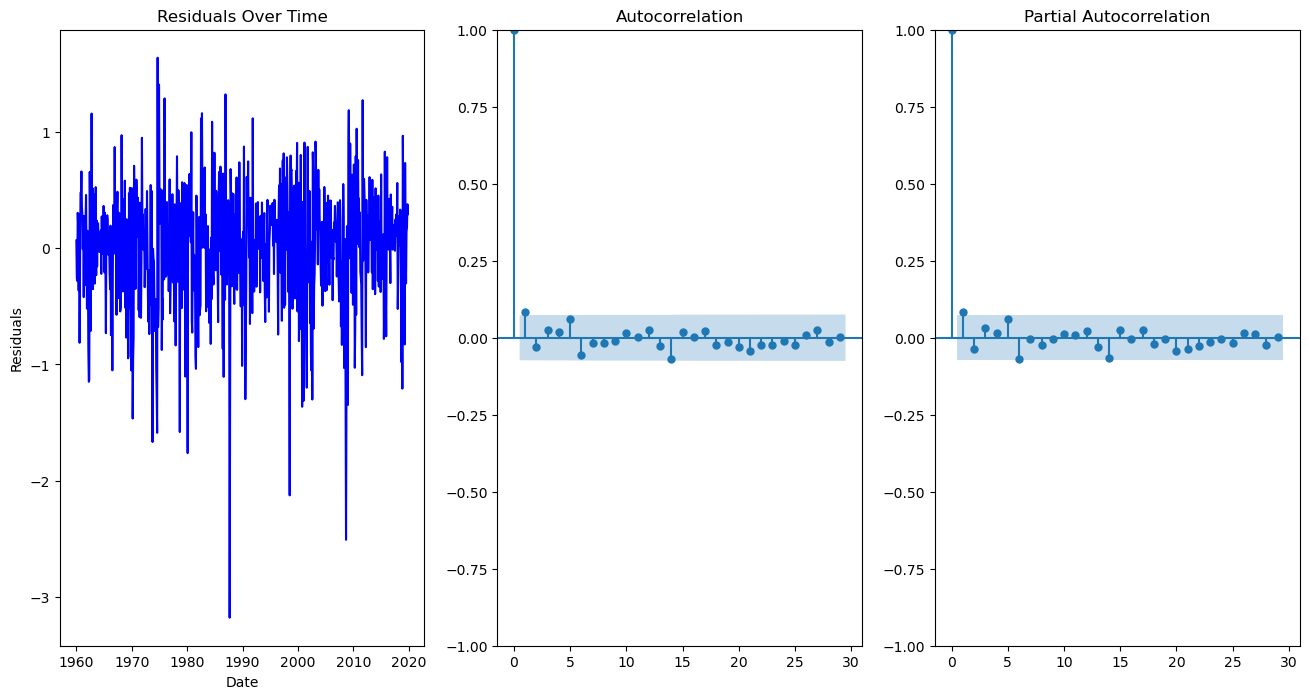

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
sns.lineplot(x=real_returns['date'], y=reg.resid, ax=axes[0], color='blue')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals Over Time')
acf = plot_acf(x=reg.resid, ax=axes[1])
pacf = plot_pacf(x=reg.resid, ax=axes[2])
plt.show()

### 2



We know that for $\hat{\beta}_{OLS}$ to be consistent, then $\hat{\beta}_{OLS} \overset{p}{\to} \beta$. Here, we have ran the regression $$r_{t+1} = \alpha + \beta dy_t + \epsilon_{t+1}$$

The OLS estimator $\hat{\beta}_{OLS}$ minimizes the in-sample mean squared error:
$$\sum_i (Y_i - X_i \beta)^2 = (Y_i - X_i \beta)' (Y_i - X_i \beta)$$
where in our case $Y_i = r_{t+1}$ and $X_i = dy_t$. 

When including an intercept in the OLS then: 
$$\hat{\beta}_{OLS} = \frac{\sum_t (dy_t - \bar{dy}) (r_{t+1} - \bar{r})}{\sum_t (dy_t - \bar{dy})^2}$$

This means that we have:
$$\hat{\beta}_{OLS} = \frac{\sum_t (dy_t - \bar{dy}) ((\alpha + \beta dy_t + \epsilon_{t+1}) - (\alpha + \beta \bar{dy} + \bar{\epsilon}))}{\sum_t (dy_t - \bar{dy})^2}$$
$$= \frac{\sum_t (dy_t - \bar{dy}) ((\beta (dy_t - \bar{dy}) + (\epsilon_{t+1}- \bar{\epsilon})))}{\sum_t (dy_t - \bar{dy})^2}$$
$$\hat{\beta}_{OLS} = \beta + \frac{\sum_t (dy_t - \bar{dy}) (\epsilon_{t+1}- \bar{\epsilon})}{\sum_t (dy_t - \bar{dy})^2} = \beta + \frac{\frac{1}{N}\sum_t (dy_t - \bar{dy}) (\epsilon_{t+1}- \bar{\epsilon})}{\frac{1}{N}\sum_t (dy_t - \bar{dy})^2}$$

Where we have by the law of large numbers: $\frac{1}{N}\sum_t (dy_t - \bar{dy}) (\epsilon_{t+1}- \bar{\epsilon}) \overset{p}{\to} Cov(dy, \epsilon)$, and $\frac{1}{N}\sum_t (dy_t - \bar{dy})^2 \overset{p}{\to} Var[dy]$

Thus:
$$plim \hat{\beta}_{OLS} = \beta + \frac{Cov(dy, \epsilon)}{Var[dy]}$$

So, for $\hat{\beta}_{OLS}$ to be consistent we need $\frac{Cov(dy, \epsilon)}{Var[dy]} = 0$. 

In [88]:
frac = real_returns['div_yld'].cov(reg.resid) / real_returns['div_yld'].var()
print(f'The covariance of divident yield and the residual over the variance of the divident yield is {frac}')

The covariance of divident yield and the residual over the variance of the divident yield is -5.32993310283118e-16


As we can see $\frac{Cov(dy, \epsilon)}{Var[dy]} = 0$, so $$plim \hat{\beta}_{OLS} = \beta$$ and the estimator is consistent.

### 3

#### Code explanation

The dataset starts with January 1960. We want the divident yield at this time to predict the returns for the 12 months that follow, ie February 1960 - January 1961. 
For this date we will use the div_yld of the same index. For the $r_{t+12,12}$ value we will shift the log_excess_returns column by 12 indeces, to capture the next twelve months.

In [45]:
k = 11
real_returns['rt12_12'] = real_returns.log_excess_ret.rolling(window = 12).sum().shift(-k)
real_returns.dropna(inplace=True)

In [46]:
real_returns

,month,year,nfirms,me,div_yld,log_excess_ret,date,rt12_12
0,1,1960,1088,2.850929e+08,0.033025,-0.072275,1960-01-01,-0.018643
1,2,1960,1092,2.881785e+08,0.033130,0.010698,1960-02-01,0.113749
2,3,1960,1096,2.841433e+08,0.033801,-0.016199,1960-03-01,0.137523
3,4,1960,1096,2.795177e+08,0.034413,-0.018143,1960-04-01,0.181859
4,5,1960,1098,2.877926e+08,0.033933,0.030841,1960-05-01,0.203642
...,...,...,...,...,...,...,...,...
704,9,2018,5797,3.647491e+10,0.018854,-0.001189,2018-09-01,-0.015693
705,10,2018,5807,3.372351e+10,0.020510,-0.079472,2018-10-01,-0.000188
706,11,2018,5801,3.415234e+10,0.020311,0.016569,2018-11-01,0.096763
707,12,2018,5780,3.094083e+10,0.022813,-0.098075,2018-12-01,0.114310


In [47]:
X = add_constant(real_returns['div_yld'])
X.columns = ['alpha', 'dividend_yield']
y = real_returns['rt12_12']

In [48]:
overlap_reg = OLS(y, X).fit(cov_type='HC3')
overlap_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                rt12_12   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     14.08
Date:                Tue, 17 Feb 2026   Prob (F-statistic):           0.000190
Time:                        22:14:04   Log-Likelihood:                 293.96
No. Observations:                 709   AIC:                            -583.9
Df Residuals:                     707   BIC:                            -574.8
Df Model:                           1                                         
Covariance Type:                  HC3                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
alpha             -0.0132      0.019     -0.707      0.480      -0.050       0.023
dividend_yield     2.2313      0.595      3.752      0.000       1.066       3.397
==============================================================================
Omnibus:                      103.439   Durbin-Watson:                   0.148
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              157.455
Skew:                          -0.976   Prob(JB):                     6.44e-35
Kurtosis:                       4.233   Cond. No.                         101.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [58]:
print(overlap_reg.t_test('dividend_yield = 0'))
print(f'R-Squared: {overlap_reg.rsquared:.4f}')

                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             2.2313      0.595      3.752      0.000       1.066       3.397
R-Squared: 0.0189


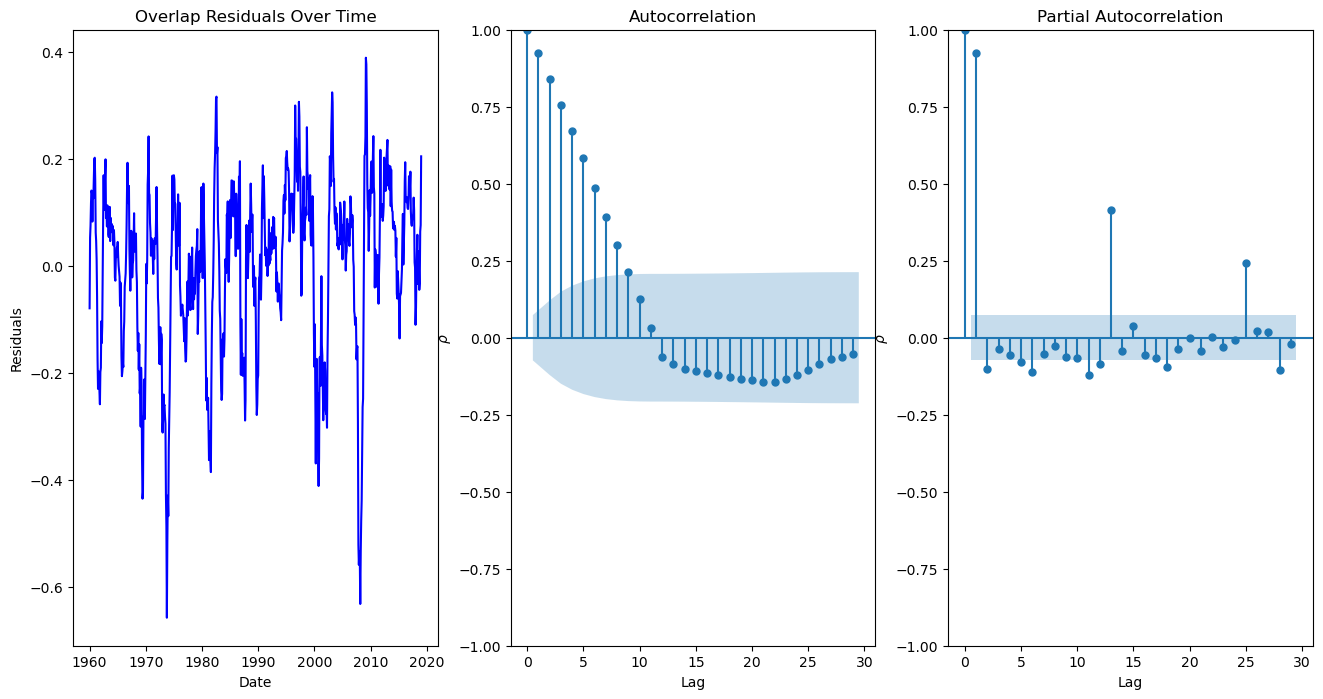

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
sns.lineplot(x=real_returns['date'], y=overlap_reg.resid, ax=axes[0], color='blue')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Overlap Residuals Over Time')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('$\\rho$')
axes[2].set_xlabel('Lag')
axes[2].set_ylabel('$\\rho$')
acf = plot_acf(x=overlap_reg.resid, ax=axes[1])
pacf = plot_pacf(x=overlap_reg.resid, ax=axes[2])
plt.show()

Looking at the residuals, PACF, and ACF it looks like the residuals follow an ARMA process. We can confirm this by fitting an ARMA(1, 11) and looking at the residuals of that to see if we can capture the dynamics of the process. The standard errors used here are the HAC errors, which correct for the autocorrelation and heteroskedasticity in the data.

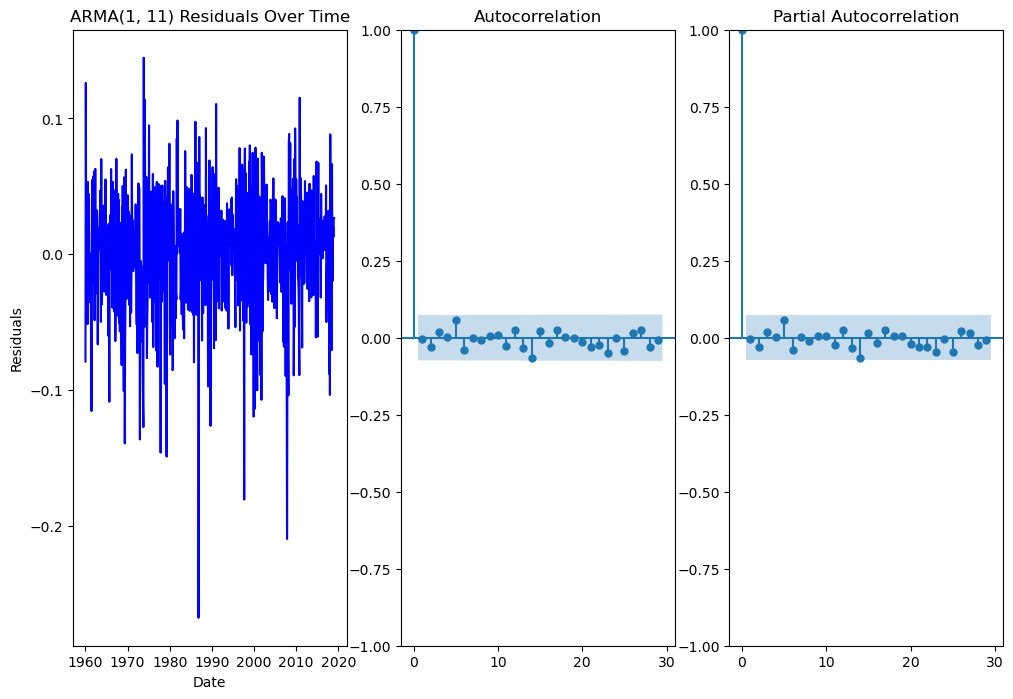

In [53]:
arima = ARIMA(overlap_reg.resid, order=(1, 0, 11), trend='n').fit(method='innovations_mle')
fig, axes = plt.subplots(1, 3, figsize=(12, 8))
sns.lineplot(x=real_returns['date'], y=arima.resid, ax=axes[0], color='blue')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residuals')
axes[0].set_title('ARMA(1, 11) Residuals Over Time')
acf = plot_acf(x=arima.resid, ax=axes[1])
pacf = plot_pacf(x=arima.resid, ax=axes[2])
plt.show()

In [54]:
arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  709
Model:                ARIMA(1, 0, 11)   Log Likelihood                1179.496
Date:                Tue, 17 Feb 2026   AIC                          -2332.993
Time:                        22:17:45   BIC                          -2273.662
Sample:                             0   HQIC                         -2310.072
                                - 709                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0760      0.034      2.244      0.025       0.010       0.142
ma.L1          0.9549      0.051     18.781      0.000       0.855       1.055
ma.L2          0.9423      0.020     46.107      0.000       0.902       0.982
ma.L3          0.9619      0.060     15.961      0.000       0.844       1.080
ma.L4          0.9694      0.037     25.912      0.000       0.896       1.043
ma.L5          0.9733      0.063     15.473      0.000       0.850       1.097
ma.L6          0.9620      0.027     35.111      0.000       0.908       1.016
ma.L7          0.9459      0.055     17.241      0.000       0.838       1.053
ma.L8          0.9288      0.026     35.925      0.000       0.878       0.979
ma.L9          0.9296      0.062     14.961      0.000       0.808       1.051
ma.L10         0.9245      0.042     22.219      0.000       0.843       1.006
ma.L11         0.9589      0.058     16.580      0.000       0.846       1.072
sigma2         0.0020      0.000     16.126      0.000       0.002       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               288.98
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               1.00   Skew:                            -0.82
Prob(H) (two-sided):                  0.97   Kurtosis:                         5.67
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

With an ARIMA(1, 0, 11) process it looks like we can capture a lot of the dynamics of the series, leaving white noise.

In [55]:
overlap_reg2 = OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 11})
overlap_reg2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                rt12_12   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     1.936
Date:                Tue, 17 Feb 2026   Prob (F-statistic):              0.165
Time:                        22:18:08   Log-Likelihood:                 293.96
No. Observations:                 709   AIC:                            -583.9
Df Residuals:                     707   BIC:                            -574.8
Df Model:                           1                                         
Covariance Type:                  HAC                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
alpha             -0.0132      0.053     -0.250      0.803      -0.117       0.090
dividend_yield     2.2313      1.604      1.392      0.164      -0.912       5.374
==============================================================================
Omnibus:                      103.439   Durbin-Watson:                   0.148
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              157.455
Skew:                          -0.976   Prob(JB):                     6.44e-35
Kurtosis:                       4.233   Cond. No.                         101.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 11 lags and without small sample correction
"""

In [57]:
print(overlap_reg2.t_test('dividend_yield = 0'))
print(f'R-Squared: {overlap_reg2.rsquared:.4f}')

                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             2.2313      1.604      1.392      0.164      -0.912       5.374
R-Squared: 0.0189
